# 🏅 Question 26 — Olympic Games ML Pipeline
### End-to-End Machine Learning System
**Dataset:**  (5000+ rows × 17 columns)

---
| Step | Description |
|------|-------------|
| 1 | Load Dataset |
| 2 | Data Cleaning |
| 3 | Normalization & Transformation |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Correlation Analysis |
| 6 | Feature Selection (PCA, Forward, Backward) |
| 7 | Classification Model (High/Medium/Low) |
| 8 | Regression Model (Predict Medal Count) |
| 9 | Model Evaluation & Plots |
| 10 | Final Summary |

In [1]:
# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.decomposition      import PCA
from sklearn.linear_model       import LinearRegression, LogisticRegression
from sklearn.ensemble           import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection  import SequentialFeatureSelector
from sklearn.metrics            import (f1_score, mean_squared_error,
                                        r2_score, classification_report,
                                        confusion_matrix)

import warnings
warnings.filterwarnings("ignore")

# Jupyter inline plots
%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Step 1 — Load Dataset

In [2]:
df = pd.read_csv("olympic_raw_dataset.csv")

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
df.head(10)

Shape   : (5050, 17)
Columns : ['Country', 'Sport', 'Year', 'Athletes', 'Gold', 'Silver', 'Bronze', 'Total_Medals', 'Events_Participated', 'GDP_Index', 'Population_Millions', 'Prev_Medals', 'Host', 'Medal_per_Athlete', 'Gold_Ratio', 'Participation_Rate', 'Medals_per_Million']


,Country,Sport,Year,Athletes,Gold,Silver,Bronze,Total_Medals,Events_Participated,GDP_Index,Population_Millions,Prev_Medals,Host,Medal_per_Athlete,Gold_Ratio,Participation_Rate,Medals_per_Million
0,New Zealand,Judo,2008.0,NaN,4.0,3.0,2.0,9.0,39.0,NaN,1143.85,10.0,0,NaN,0.4444,NaN,0.0079
1,Iran,Rowing,2012.0,30.0,2.0,4.0,1.0,7.0,1.0,0.458,408.30,5.0,0,0.2333,0.2857,30.0000,0.0171
2,Mexico,Shooting,2000.0,6.0,2.0,1.0,4.0,7.0,29.0,0.361,326.65,5.0,0,1.1667,0.2857,0.2069,0.0214
3,Estonia,Athletics,2004.0,6.0,NaN,2.0,1.0,NaN,2.0,NaN,649.99,4.0,0,NaN,NaN,3.0000,NaN
4,Malaysia,Weightlifting,2020.0,38.0,2.0,1.0,4.0,7.0,32.0,NaN,355.92,6.0,0,0.1842,0.2857,1.1875,0.0197
5,Bulgaria,Shooting,2016.0,41.0,4.0,1.0,2.0,7.0,37.0,0.758,208.03,NaN,0,0.1707,0.5714,1.1081,0.0336
6,Colombia,Judo,2020.0,1.0,NaN,1.0,1.0,2.0,26.0,0.319,126.92,2.0,0,2.0000,NaN,0.0385,0.0158
7,Georgia,Rowing,2020.0,9.0,3.0,2.0,4.0,9.0,38.0,0.254,486.18,7.0,0,1.0000,0.3333,0.2368,0.0185
8,Cambodia,Weightlifting,2024.0,52.0,2.0,2.0,3.0,7.0,46.0,0.451,680.41,6.0,0,0.1346,0.2857,1.1304,0.0103
9,Russia,Boxing,2024.0,46.0,3.0,4.0,1.0,8.0,36.0,0.126,554.33,8.0,0,0.1739,0.3750,1.2778,0.0144


## Step 2 — Data Cleaning

In [3]:
# Missing values BEFORE cleaning
print("Missing values BEFORE cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0])

Missing values BEFORE cleaning:
Athletes               400
Gold                   402
Silver                 405
Bronze                 403
Total_Medals           403
Events_Participated    404
GDP_Index              400
Population_Millions    405
Prev_Medals            407
Medal_per_Athlete      775
Gold_Ratio             762
Participation_Rate     774
Medals_per_Million     778
dtype: int64


In [14]:
# 2a. Fix Year column  (e.g. '2000.0' → 2000)
df["Year"] = df["Year"].astype(str).str.replace(".0", "", regex=False)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# 2b. Fix inconsistent country names
df["Country"] = df["Country"].str.strip().str.title()
df["Country"] = df["Country"].replace({
    "Usa": "USA", "U.K.": "UK",
    "China": "China", "Russia": "Russia",
    "Germany": "Germany", "France": "France"
})

# 2c. Remove duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed : {before - len(df)}")

# 2d. Fix negative values
for col in ["Gold", "Silver", "Bronze"]:
    df[col] = df[col].apply(lambda x: abs(x) if pd.notna(x) and x < 0 else x)

# 2e. Fix outliers in Athletes using IQR
Q1, Q3 = df["Athletes"].quantile(0.25), df["Athletes"].quantile(0.75)
upper  = Q3 + 1.5 * (Q3 - Q1)
df["Athletes"] = df["Athletes"].apply(
    lambda x: df["Athletes"].median() if pd.notna(x) and x > upper else x
)

# 2f. Fill missing values with median
num_cols = ["Athletes","Gold","Silver","Bronze","Total_Medals",
            "Events_Participated","GDP_Index","Population_Millions","Prev_Medals"]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 2g. Recalculate engineered columns
df["Total_Medals"]       = df["Gold"] + df["Silver"] + df["Bronze"]
df["Medal_per_Athlete"]  = (df["Total_Medals"] / df["Athletes"]).round(4)
df["Gold_Ratio"]         = (df["Gold"]  / df["Total_Medals"].replace(0,1)).round(4)
df["Participation_Rate"] = (df["Athletes"] / df["Events_Participated"]).round(4)
df["Medals_per_Million"] = (df["Total_Medals"] / df["Population_Millions"]).round(4)

print("✅ Data cleaned successfully")
print(f"Clean shape : {df.shape}")
df.head()

Duplicates removed : 47
✅ Data cleaned successfully
Clean shape : (4600, 19)


,Country,Sport,Year,Athletes,Gold,Silver,Bronze,Total_Medals,Events_Participated,GDP_Index,Population_Millions,Prev_Medals,Host,Medal_per_Athlete,Gold_Ratio,Participation_Rate,Medals_per_Million,Country_Code,Sport_Code
0,New Zealand,Judo,2008,31.0,4.0,3.0,2.0,9.0,39.0,0.549,1143.85,10.0,0,0.2903,0.4444,0.7949,0.0079,52,4
1,Iran,Rowing,2012,30.0,2.0,4.0,1.0,7.0,1.0,0.458,408.30,5.0,0,0.2333,0.2857,30.0000,0.0171,36,5
2,Mexico,Shooting,2000,6.0,2.0,1.0,4.0,7.0,29.0,0.361,326.65,5.0,0,1.1667,0.2857,0.2069,0.0214,47,6
3,Malaysia,Weightlifting,2020,38.0,2.0,1.0,4.0,7.0,32.0,0.549,355.92,6.0,0,0.1842,0.2857,1.1875,0.0197,46,8
4,Bulgaria,Shooting,2016,41.0,4.0,1.0,2.0,7.0,37.0,0.758,208.03,4.0,0,0.1707,0.5714,1.1081,0.0336,10,6


In [15]:
# Missing values AFTER cleaning
print("Missing values AFTER cleaning:")
print(df.isnull().sum())

Missing values AFTER cleaning:
Country                0
Sport                  0
Year                   0
Athletes               0
Gold                   0
Silver                 0
Bronze                 0
Total_Medals           0
Events_Participated    0
GDP_Index              0
Population_Millions    0
Prev_Medals            0
Host                   0
Medal_per_Athlete      0
Gold_Ratio             0
Participation_Rate     0
Medals_per_Million     0
Country_Code           0
Sport_Code             0
dtype: int64


In [6]:
# Statistical summary
df[["Athletes","Gold","Silver","Bronze","Total_Medals","GDP_Index"]].describe().round(2)

,Athletes,Gold,Silver,Bronze,Total_Medals,GDP_Index
count,4650.00,4648.00,4645.00,4647.00,4647.00,4650.00
mean,78.00,1.77,1.51,1.55,4.86,0.62
std,602.25,1.61,1.54,1.45,3.76,0.97
min,1.00,-9.93,-9.48,0.00,0.00,0.10
25%,16.00,0.00,0.00,0.00,1.00,0.32
50%,31.00,2.00,1.00,1.00,4.00,0.55
75%,45.00,3.00,3.00,3.00,8.00,0.78
max,9620.42,5.00,5.00,5.00,15.00,18.45


## Step 3 — Normalization & Transformation

In [7]:
# Label encode categorical columns
le_country = LabelEncoder()
le_sport   = LabelEncoder()
df["Country_Code"] = le_country.fit_transform(df["Country"])
df["Sport_Code"]   = le_sport.fit_transform(df["Sport"])

# Define feature set
features = ["Athletes", "Events_Participated", "GDP_Index",
            "Population_Millions", "Prev_Medals", "Host",
            "Medal_per_Athlete", "Gold_Ratio",
            "Participation_Rate", "Medals_per_Million",
            "Country_Code", "Year", "Sport_Code"]

X     = df[features].copy()
y_reg = df["Total_Medals"]

# Drop rows where target is NaN
valid_idx = y_reg.dropna().index
X         = X.loc[valid_idx].reset_index(drop=True)
y_reg     = y_reg.loc[valid_idx].reset_index(drop=True)
df        = df.loc[valid_idx].reset_index(drop=True)

# Fill remaining NaN in features with median
X = X.fillna(X.median())

# StandardScaler normalization
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print(f"✅ Normalized {len(features)} features for {len(X_scaled)} samples")
X_scaled.describe().round(2)

✅ Normalized 13 features for 4647 samples


,Athletes,Events_Participated,GDP_Index,Population_Millions,Prev_Medals,Host,Medal_per_Athlete,Gold_Ratio,Participation_Rate,Medals_per_Million,Country_Code,Year,Sport_Code
count,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00,4647.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.13,-1.77,-0.55,-1.78,-1.21,-0.09,-0.35,-25.69,-0.05,-0.18,-1.72,-1.54,-1.56
25%,-0.10,-0.81,-0.29,-0.85,-0.94,-0.09,-0.31,-0.80,-0.04,-0.16,-0.88,-0.77,-0.86
50%,-0.08,0.00,-0.07,0.00,-0.13,-0.09,-0.23,0.03,-0.04,-0.13,0.01,0.00,-0.16
75%,-0.05,0.82,0.16,0.83,0.67,-0.09,-0.11,0.45,-0.03,-0.08,0.85,0.77,0.89
max,16.50,1.78,19.17,1.79,3.37,10.73,12.17,1.71,66.20,39.09,1.82,1.54,1.59


## Step 4 — Exploratory Data Analysis (EDA)

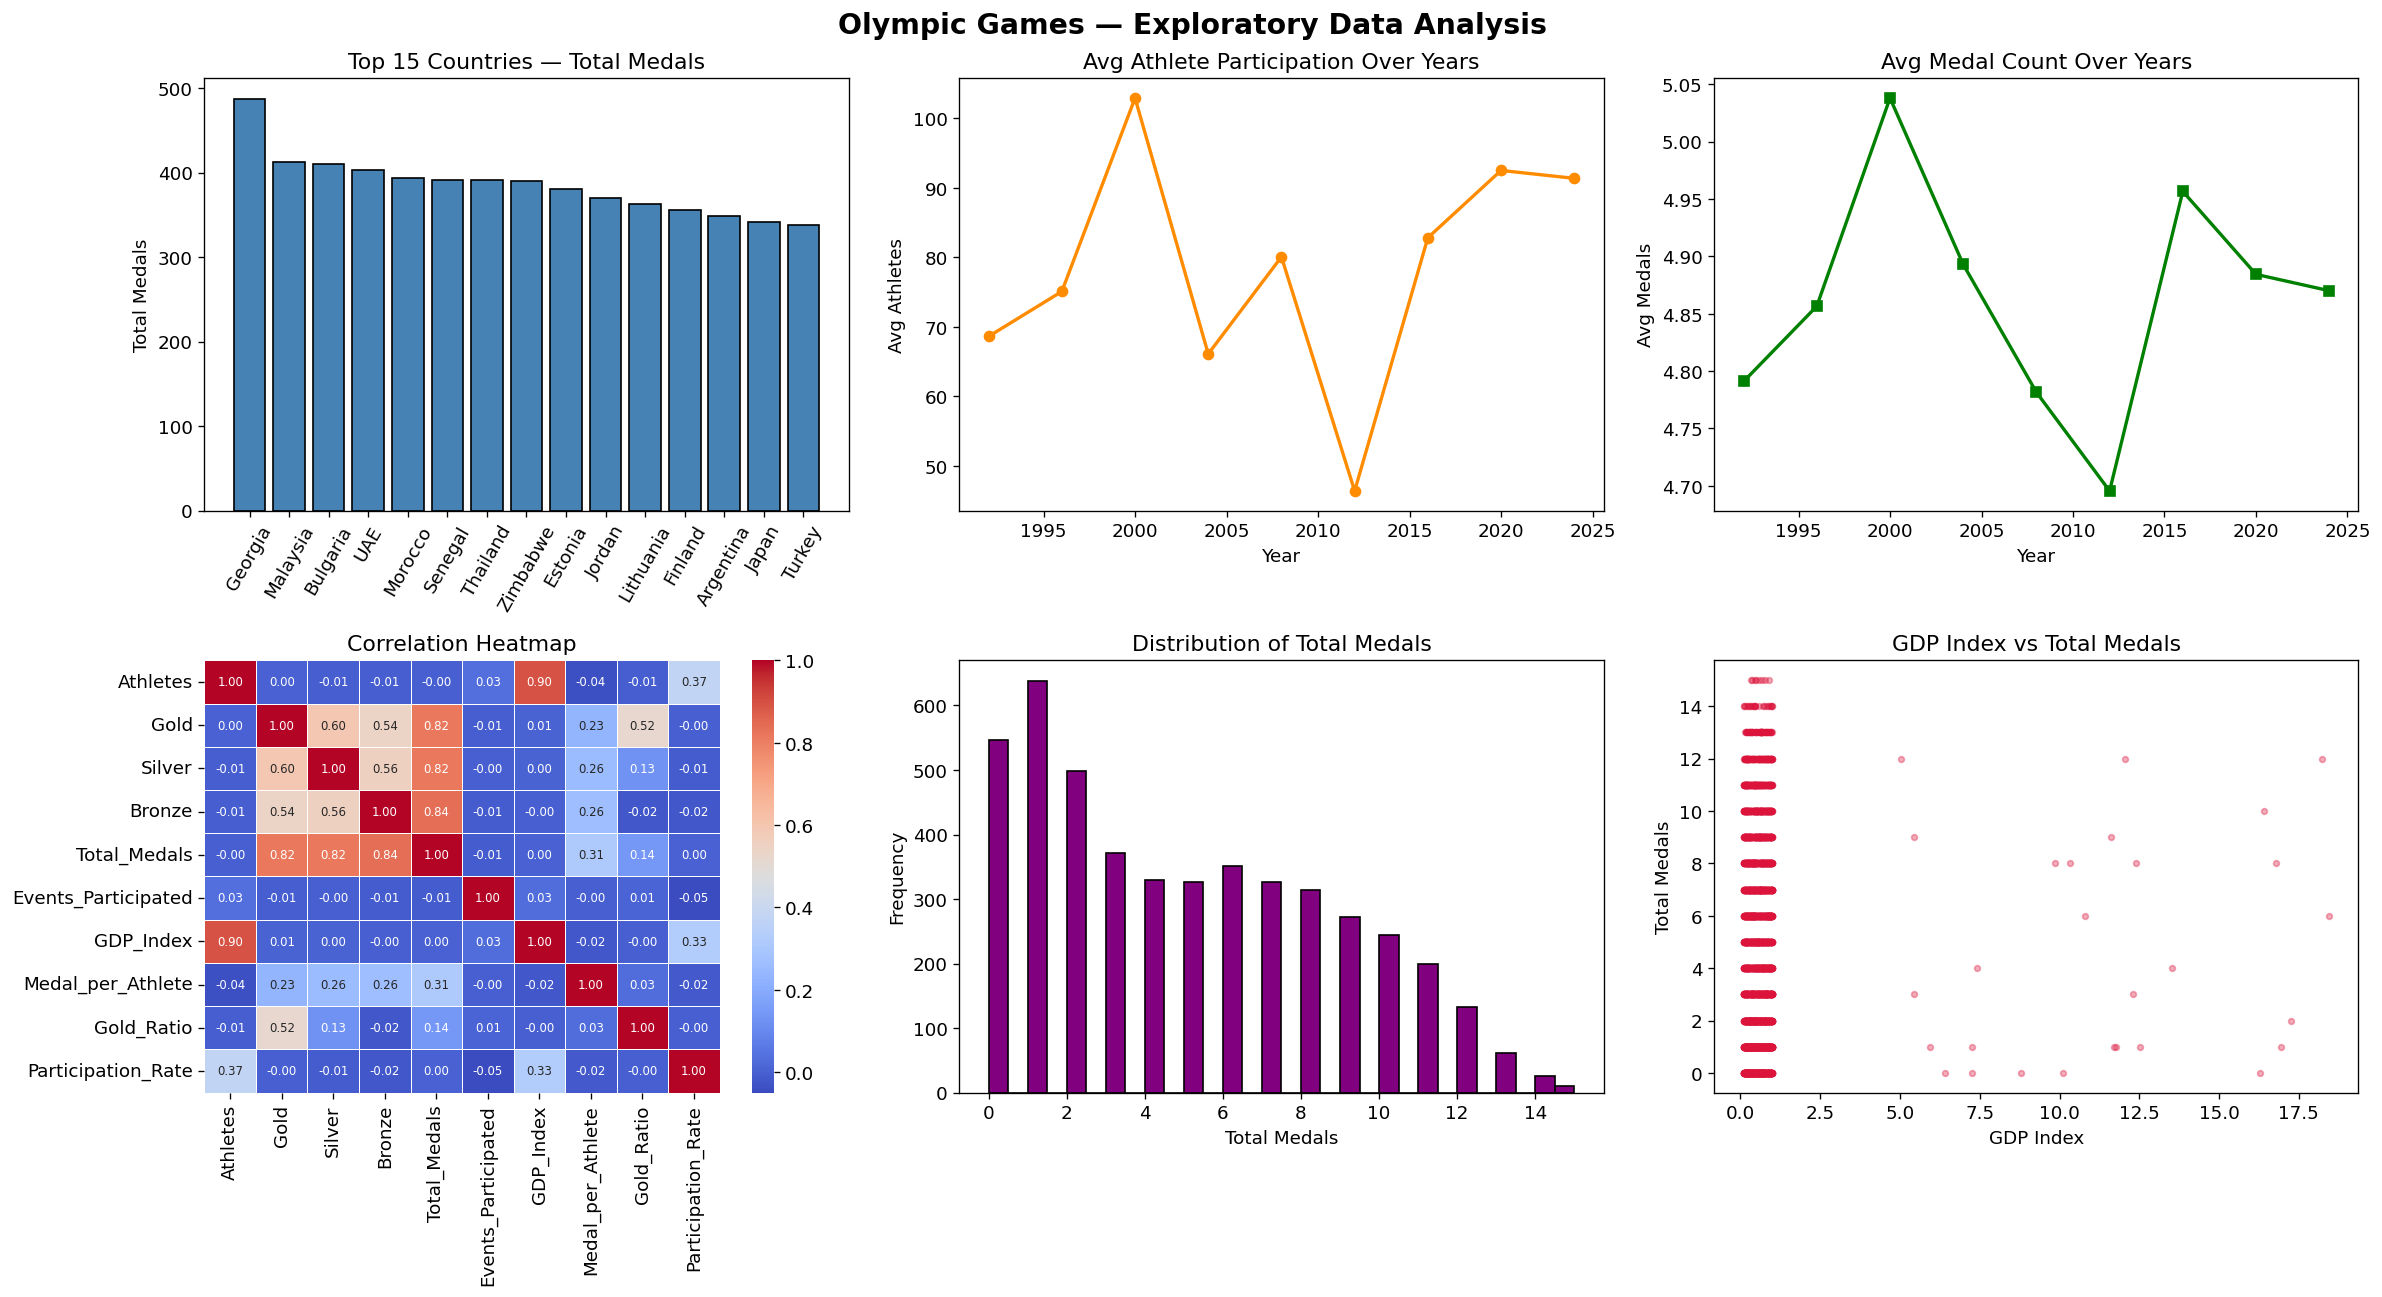

✅ EDA plots displayed


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Olympic Games — Exploratory Data Analysis",
             fontsize=17, fontweight="bold")

# (a) Bar chart — Top 15 countries
top15 = df.groupby("Country")["Total_Medals"].sum().nlargest(15)
axes[0,0].bar(top15.index, top15.values, color="steelblue", edgecolor="black")
axes[0,0].set_title("Top 15 Countries — Total Medals")
axes[0,0].set_ylabel("Total Medals")
axes[0,0].tick_params(axis="x", rotation=60)

# (b) Line plot — Athlete participation over years
yr_ath = df.groupby("Year")["Athletes"].mean()
axes[0,1].plot(yr_ath.index, yr_ath.values, marker="o", color="darkorange", linewidth=2)
axes[0,1].set_title("Avg Athlete Participation Over Years")
axes[0,1].set_xlabel("Year"); axes[0,1].set_ylabel("Avg Athletes")

# (c) Line plot — Avg medals over years
yr_med = df.groupby("Year")["Total_Medals"].mean()
axes[0,2].plot(yr_med.index, yr_med.values, marker="s", color="green", linewidth=2)
axes[0,2].set_title("Avg Medal Count Over Years")
axes[0,2].set_xlabel("Year"); axes[0,2].set_ylabel("Avg Medals")

# (d) Heatmap — Correlation
corr_cols = ["Athletes","Gold","Silver","Bronze","Total_Medals",
             "Events_Participated","GDP_Index","Medal_per_Athlete",
             "Gold_Ratio","Participation_Rate"]
sns.heatmap(df[corr_cols].corr(), ax=axes[1,0], annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.4, annot_kws={"size": 7})
axes[1,0].set_title("Correlation Heatmap")

# (e) Histogram — Medal distribution
axes[1,1].hist(df["Total_Medals"], bins=30, color="purple", edgecolor="black")
axes[1,1].set_title("Distribution of Total Medals")
axes[1,1].set_xlabel("Total Medals"); axes[1,1].set_ylabel("Frequency")

# (f) Scatter — GDP vs Medals
axes[1,2].scatter(df["GDP_Index"], df["Total_Medals"], alpha=0.35, color="crimson", s=12)
axes[1,2].set_title("GDP Index vs Total Medals")
axes[1,2].set_xlabel("GDP Index"); axes[1,2].set_ylabel("Total Medals")

plt.tight_layout()
plt.show()
print("✅ EDA plots displayed")

## Step 5 — Correlation Analysis

Correlation with Total_Medals (sorted):
Bronze                 0.8378
Gold                   0.8180
Silver                 0.8160
Medal_per_Athlete      0.3135
Gold_Ratio             0.1419
GDP_Index              0.0019
Participation_Rate     0.0015
Athletes              -0.0035
Events_Participated   -0.0124
Name: Total_Medals, dtype: float64


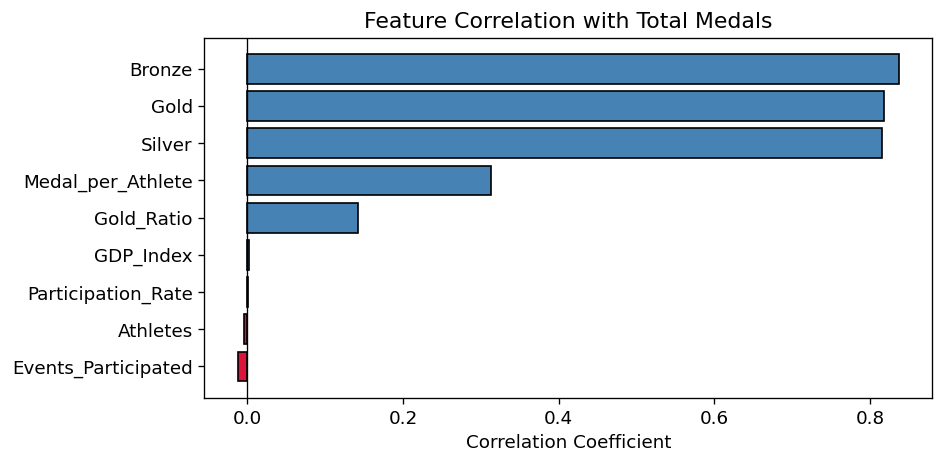

In [9]:
corr_with_medals = df[corr_cols].corr()["Total_Medals"].drop("Total_Medals")

print("Correlation with Total_Medals (sorted):")
print(corr_with_medals.sort_values(ascending=False).round(4))

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
corr_sorted = corr_with_medals.sort_values()
colors = ["crimson" if v < 0 else "steelblue" for v in corr_sorted]
ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Total Medals")
ax.set_xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## Step 6 — Feature Selection (PCA, Forward, Backward)

PCA: 13 features → 12 components 
     Variance retained: 99.2%


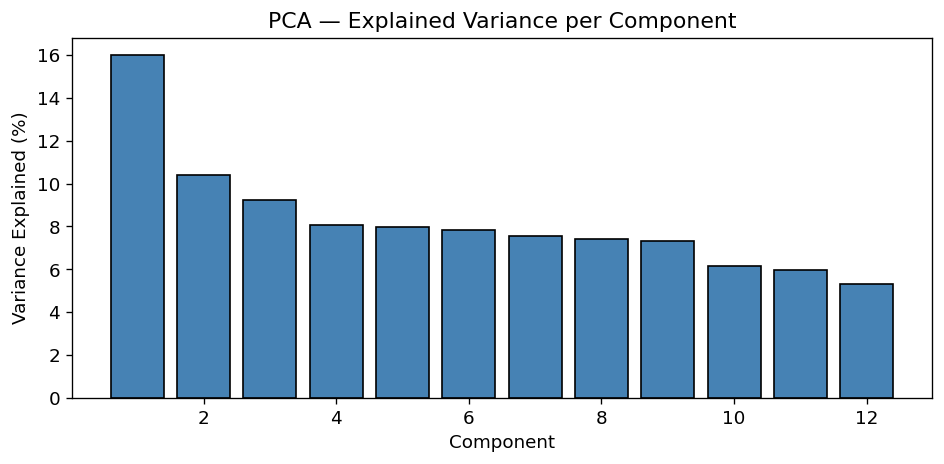

In [10]:
# 6a. PCA
pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]} features → {X_pca.shape[1]} components ")
print(f"     Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# PCA variance plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(pca.explained_variance_ratio_)+1),
       pca.explained_variance_ratio_*100, color="steelblue", edgecolor="black")
ax.set_title("PCA — Explained Variance per Component")
ax.set_xlabel("Component"); ax.set_ylabel("Variance Explained (%)")
plt.tight_layout(); plt.show()

In [ ]:
# 6b. Forward Selection
rf_est = RandomForestRegressor(n_estimators=50, random_state=42)
fwd    = SequentialFeatureSelector(rf_est, n_features_to_select=6,
                                    direction="forward", cv=3)
fwd.fit(x_scaled, y_reg)
fwd_feats = [features[i] for i, v in enumerate(fwd.get_support()) if v]
print(f"✅ Forward Selection features  : {fwd_feats}")

# 6c. Backward Selection
bwd = SequentialFeatureSelector(rf_est, n_features_to_select=6,
                                 direction="backward", cv=3)
bwd.fit(x_scaled, y_reg)
bwd_feats = [features[i] for i, v in enumerate(bwd.get_support()) if v]
print(f"✅ Backward Selection features : {bwd_feats}")

## Step 7 — Classification Model (High / Medium / Low Performance)

In [ ]:
# Create performance labels
q33 = df["Total_Medals"].quantile(0.33)
q66 = df["Total_Medals"].quantile(0.66)

df["Performance"] = df["Total_Medals"].apply(
    lambda v: "High" if v >= q66 else ("Medium" if v >= q33 else "Low")
)

print("Class distribution:")
print(df["Performance"].value_counts())

y_cls = df["Performance"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
print(f"
Train size: {len(X_tr)}  |  Test size: {len(X_te)}")

In [ ]:
cls_results = {}

for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=500, random_state=42)),
    ("Random Forest",        RandomForestClassifier(n_estimators=100, random_state=42))
]:
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    f1    = f1_score(y_te, preds, average="weighted")
    cls_results[name] = f1
    print(f"
{'='*50}")
    print(f" {name}  —  F1 Score = {f1:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_te, preds, zero_division=0))

In [ ]:
# Confusion Matrix — Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_tr, y_tr)
y_pred = rf_clf.predict(X_te)
labels = ["High", "Low", "Medium"]
cm     = confusion_matrix(y_te, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=0.5, annot_kws={"size": 13})
ax.set_title("Confusion Matrix — Random Forest Classifier", fontsize=14)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## Step 8 — Regression Model (Predict Medal Count)

In [ ]:
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

reg_results = {}

for name, model in [
    ("Linear Regression", LinearRegression()),
    ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=42))
]:
    model.fit(X_tr_r, y_tr_r)
    preds = model.predict(X_te_r)
    rmse  = np.sqrt(mean_squared_error(y_te_r, preds))
    r2    = r2_score(y_te_r, preds)
    reg_results[name] = {"RMSE": round(rmse, 4), "R2": round(r2, 4)}
    print(f"{name:<22}  RMSE = {rmse:.4f}   R² = {r2:.4f}")

## Step 9 — Model Evaluation Plots

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation Results", fontsize=15, fontweight="bold")

nr   = list(reg_results.keys())
rmse_v = [reg_results[n]["RMSE"] for n in nr]
r2_v   = [reg_results[n]["R2"]   for n in nr]

axes[0].bar(nr, rmse_v, color=["steelblue","darkorange"], edgecolor="black")
axes[0].set_title("Regression — RMSE (lower ↓)"); axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(nr, r2_v, color=["steelblue","darkorange"], edgecolor="black")
axes[1].set_title("Regression — R² (higher ↑)"); axes[1].set_ylim(0, 1)
axes[1].set_ylabel("R²"); axes[1].tick_params(axis="x", rotation=15)

nc  = list(cls_results.keys())
f1v = [cls_results[n] for n in nc]
axes[2].bar(nc, f1v, color=["purple","crimson"], edgecolor="black")
axes[2].set_title("Classification — F1 Score (higher ↑)"); axes[2].set_ylim(0, 1)
axes[2].set_ylabel("F1 Score"); axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

## Step 10 — Final Summary

In [ ]:
print("=" * 60)
print("  PIPELINE SUMMARY — Question 26")
print("=" * 60)
print(f"Dataset rows             : {df.shape[0]}")
print(f"Features used            : {len(features)}")
print(f"PCA components           : {X_pca.shape[1]}")
print(f"Forward Selection feats  : {fwd_feats}")
print(f"Backward Selection feats : {bwd_feats}")
print("")
print("Regression Results:")
for k, v in reg_results.items():
    print(f"  {k:<22}: RMSE={v['RMSE']}  R²={v['R2']}")
print("")
print("Classification F1 Score:")
for k, v in cls_results.items():
    print(f"  {k:<22}: F1={v:.4f}")
print("")
print("✅ Complete ML pipeline executed successfully!")